In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import glob
# from upsetplot import from_contents, plot
from matplotlib import pyplot

from pathlib import Path

from dfmodel import DigitalFamilyBinary
from networkx.classes import non_neighbors

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial")

In [2]:
design_matrix = pd.read_csv(
    "../0_clinical_data/design_matrix_train.tsv",
    sep='\t'
)

In [3]:
from sklearn.model_selection import train_test_split

design_matrix, design_matrix_test = train_test_split(design_matrix, test_size=0.2, random_state=42, stratify=design_matrix["sepsis_or_septic_shock"])

In [4]:
design_matrix['survival_days'] = design_matrix['survival_days'].fillna(design_matrix['survival_days'].max())

In [5]:
design_matrix_test['survival_days'] = design_matrix_test['survival_days'].fillna(design_matrix_test['survival_days'].max())

In [6]:
design_matrix['organ_dysfunction'] = ((design_matrix[['sofa_score_increase_day1', 'sofa_score_increase_day2', 'sofa_score_increase_day3']] > 1).any(axis=1)).astype(int)
design_matrix_test['organ_dysfunction'] = ((design_matrix_test[['sofa_score_increase_day1', 'sofa_score_increase_day2', 'sofa_score_increase_day3']] > 1).any(axis=1)).astype(int)

In [7]:
design_matrix.shape

(544, 72)

In [8]:
clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "mental_status_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "crp_day1",
    "trc_emergency_department",
    "sex",
    "age"
]

continuous_clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "trc_emergency_department",
    "crp_day1",
    "age"
]

categorical_clinical_columns = [
    "mental_status_ambulance",
]

In [9]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer, MinMaxScaler
from sklearn.impute import SimpleImputer

training_data = design_matrix.copy()
testing_data = design_matrix_test.copy()

clinical_scaler = StandardScaler()

clinical_imputer = SimpleImputer()
min_max_scaler = MinMaxScaler()
sex_scaler = MinMaxScaler((0, 1))
constant_imputer = SimpleImputer(strategy="constant", fill_value=1.0)

training_data[continuous_clinical_columns] = clinical_imputer.fit_transform(training_data[continuous_clinical_columns])
training_data[["mental_status_ambulance"]] = constant_imputer.fit_transform(training_data[["mental_status_ambulance"]])

training_data[continuous_clinical_columns] = clinical_scaler.fit_transform(training_data[continuous_clinical_columns])
training_data[['sex']] = sex_scaler.fit_transform(training_data[['sex']])
#training_data[clinical_columns] = min_max_scaler.fit_transform(training_data[clinical_columns])

testing_data[continuous_clinical_columns] = clinical_imputer.transform(testing_data[continuous_clinical_columns])
testing_data[["mental_status_ambulance"]] = constant_imputer.transform(testing_data[["mental_status_ambulance"]])

testing_data[continuous_clinical_columns] = clinical_scaler.transform(testing_data[continuous_clinical_columns])
testing_data[['sex']] = sex_scaler.transform(testing_data[['sex']])
#testing_data[clinical_columns] = min_max_scaler.transform(testing_data[clinical_columns])

In [10]:
n_neighbors = [1, 5, 10, 15, 20, 25, 30, 50, 100, 200]

In [11]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score
from sklearn.metrics import pairwise_distances

n_neighbor_distances = dict()

distances_ = []
std_ = []
aucs = []
recalls = []
precisions = []

infection_aucs = []
infection_recalls = []
infection_precisions = []

sepsis_aucs = []
sepsis_recalls = []
sepsis_precisions = []

organ_dysfunction_aucs = []
organ_dysfunction_recalls = []
organ_dysfunction_precisions = []

graphs = []

for n_neighbor in n_neighbors:

    df_estimator = DigitalFamilyBinary(
        n_neighbors=n_neighbor,
        bootstrap_iterations=100
    )

    df_estimator.fit(training_data, features=clinical_columns)

    distances, neighbors = df_estimator.neighbors(testing_data, features=clinical_columns)

    def prediction_metrics(target_column):
        predictions = df_estimator.predict(testing_data, features=clinical_columns, target_column=target_column, bootstrap=False)
        auc_score = roc_auc_score(testing_data[target_column], predictions)
        recall = recall_score(testing_data[target_column], np.where(np.array(predictions) > 0.5, 1, 0))
        precision = precision_score(testing_data[target_column], np.where(np.array(predictions) > 0.5, 1, 0))
        return auc_score, recall, precision

    auc_score, recall, precision = prediction_metrics("sepsis_or_septic_shock")
    sepsis_aucs.append(auc_score)
    sepsis_recalls.append(recall)
    sepsis_precisions.append(precision)

    distances_.append(np.mean(distances.mean(axis=1)))
    std_.append(np.std(distances.mean(axis=1)))
    avg_dists = []

    graphs.append(df_estimator.network_)

    # for i in range(testing_data.shape[0]):
    #
    #     knn_idx = neighbors[i, :]
    #
    #     neighborhood = training_data.iloc[knn_idx, :].copy()
    #
    #     D = pairwise_distances(neighborhood[clinical_columns], metric="euclidean")
    #
    #     avg_dists.append(D[np.triu_indices_from(D, k=1)].mean())
    #
    print(n_neighbor, np.mean(distances.mean(axis=1)), np.std(distances.mean(axis=1)), auc_score, recall, precision)

1 1.8847431871913238 0.5888243498276907 0.5516379094773693 0.7311827956989247 0.7157894736842105
5 2.16993056490058 0.6175343955977283 0.6692923230807701 0.7741935483870968 0.7422680412371134
10 2.3411461458569884 0.6568092834378795 0.6825456364091023 0.8064516129032258 0.7653061224489796
15 2.4540780278681105 0.6889765430574878 0.6604151037759441 0.9032258064516129 0.75
20 2.5387195745885984 0.7127309619517431 0.6904226056514129 0.9032258064516129 0.75
25 2.607204221051329 0.7321716203516182 0.6985496374093524 0.9032258064516129 0.7241379310344828
30 2.665087097468688 0.7483716486403904 0.7119279819954989 0.9139784946236559 0.7327586206896551
50 2.837742136634771 0.7961802494025179 0.7456864216054013 0.967741935483871 0.72
100 3.109428230366525 0.8527304755360935 0.7549387346836709 1.0 0.6888888888888889
200 3.4521744086142467 0.8864649316734587 0.738434608652163 1.0 0.6838235294117647


In [12]:
results = pd.DataFrame(
    {
        "n_neighbors": n_neighbors,
        "distance": distances_,
        "std": std_,
        "sepsis_auc": sepsis_aucs,
        "sepsis_recall": sepsis_recalls,
        "sepsis_precision": sepsis_precisions,
    }
)

In [13]:
results.to_csv(
    "distance_results.tsv",
    sep="\t",
    index=False,
)

<Axes: xlabel='n_neighbors', ylabel='distance'>

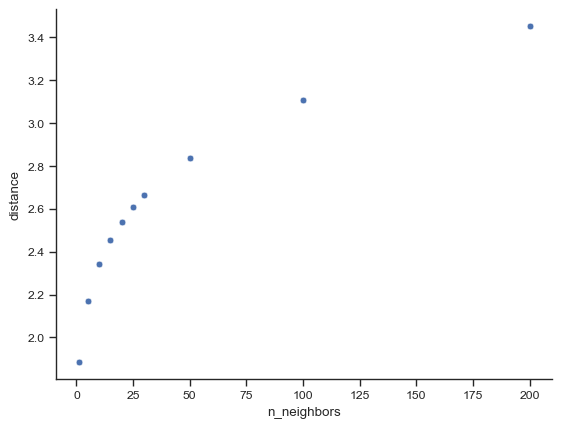

In [14]:
sns.scatterplot(
    data=results,
    x="n_neighbors",
    y="distance",
)

<Axes: xlabel='n_neighbors', ylabel='std'>

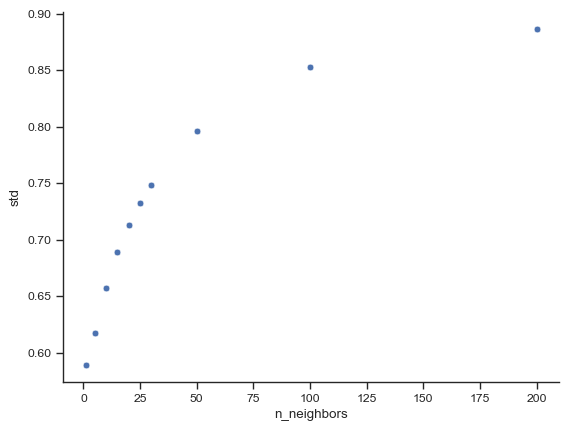

In [15]:
sns.scatterplot(
    data=results,
    x="n_neighbors",
    y="std",
)

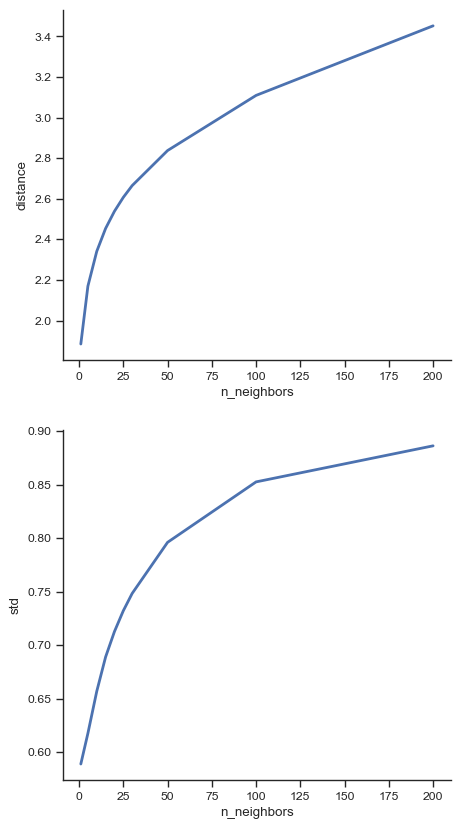

In [16]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=2,
    ncols=1,
    #gridspec_kw={"width_ratios": (1, 1)},
)

axs = axs.flatten()

sns.lineplot(
    data=results,
    x="n_neighbors",
    y="distance",
    ax=axs[0],
    lw=2
)

sns.lineplot(
    data=results,
    x="n_neighbors",
    y="std",
    ax=axs[1],
    lw=2
)
sns.despine()
fig.set_size_inches((5, 10))

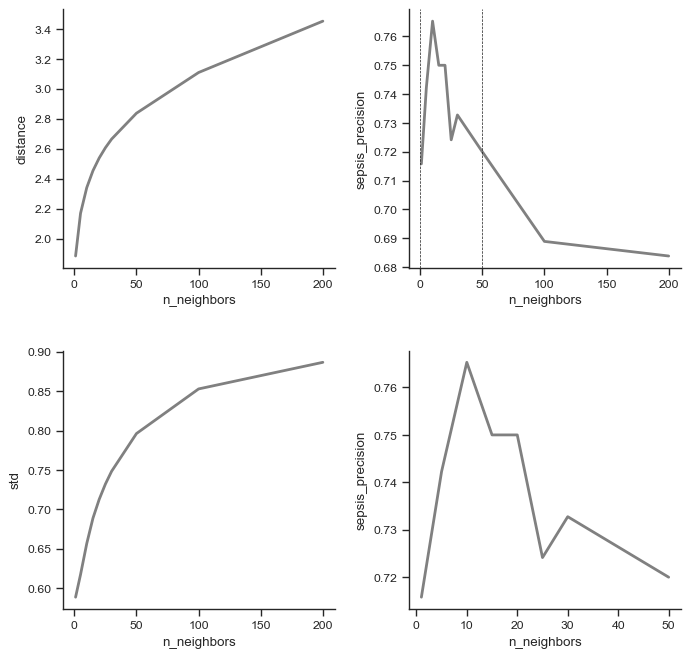

In [17]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=2,
    ncols=2,
    #gridspec_kw={"width_ratios": (1, 1)},
)

axs = axs.flatten()

sns.lineplot(
    data=results,
    x="n_neighbors",
    y="distance",
    ax=axs[0],
    color="gray",
    lw=2
)

sns.lineplot(
    data=results,
    x="n_neighbors",
    y="std",
    ax=axs[2],
    color="gray",
    lw=2
)

sns.lineplot(
    data=results,
    x="n_neighbors",
    y="sepsis_precision",
    color="gray",
    ax=axs[1],
    lw=2
)

sns.lineplot(
    data=results[results['n_neighbors'] < 100],
    x="n_neighbors",
    y="sepsis_precision",
    color="gray",
    ax=axs[3],
    lw=2
)


axs[1].axvline(0, color="k", linestyle="--", linewidth=0.5)
axs[1].axvline(50, color="k", linestyle="--", linewidth=0.5)

sns.despine()
plt.tight_layout()
fig.set_size_inches((7, 7))

In [18]:
fig.savefig(
    "precision_n_neighbors.pdf", dpi=300, bbox_inches="tight"
)

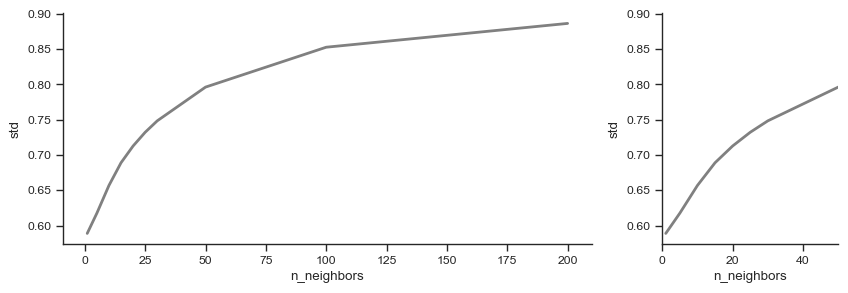

In [19]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=1,
    ncols=2,
    gridspec_kw={"width_ratios": (3, 1)},
)

sns.lineplot(
    data=results,
    x="n_neighbors",
    y="std",
    ax=axs[0],
    color="gray",
    lw=2
)

sns.lineplot(
    data=results,
    x="n_neighbors",
    y="std",
    ax=axs[1],
    color="gray",
    lw=2
)

axs[1].set_xlim((-0.05, 50))

fig.set_size_inches((10, 3))

In [20]:
n_neighbors

[1, 5, 10, 15, 20, 25, 30, 50, 100, 200]

100%|██████████| 1000/1000 [00:01<00:00, 672.96it/s]


BarnesHut Approximation  took  0.42  seconds
Repulsion forces  took  0.88  seconds
Gravitational forces  took  0.02  seconds
Attraction forces  took  0.00  seconds
AdjustSpeedAndApplyForces step  took  0.09  seconds


100%|██████████| 1000/1000 [00:01<00:00, 501.83it/s]


BarnesHut Approximation  took  0.46  seconds
Repulsion forces  took  1.34  seconds
Gravitational forces  took  0.02  seconds
Attraction forces  took  0.01  seconds
AdjustSpeedAndApplyForces step  took  0.09  seconds


100%|██████████| 1000/1000 [00:01<00:00, 512.08it/s]


...

BarnesHut Approximation  took  0.42  seconds
Repulsion forces  took  1.19  seconds
Gravitational forces  took  0.02  seconds
Attraction forces  took  0.11  seconds
AdjustSpeedAndApplyForces step  took  0.09  seconds


100%|██████████| 1000/1000 [00:01<00:00, 529.53it/s]


BarnesHut Approximation  took  0.41  seconds
Repulsion forces  took  1.09  seconds
Gravitational forces  took  0.02  seconds
Attraction forces  took  0.21  seconds
AdjustSpeedAndApplyForces step  took  0.09  seconds


100%|██████████| 1000/1000 [00:02<00:00, 497.40it/s]


BarnesHut Approximation  took  0.41  seconds
Repulsion forces  took  1.03  seconds
Gravitational forces  took  0.02  seconds
Attraction forces  took  0.39  seconds
AdjustSpeedAndApplyForces step  took  0.09  seconds


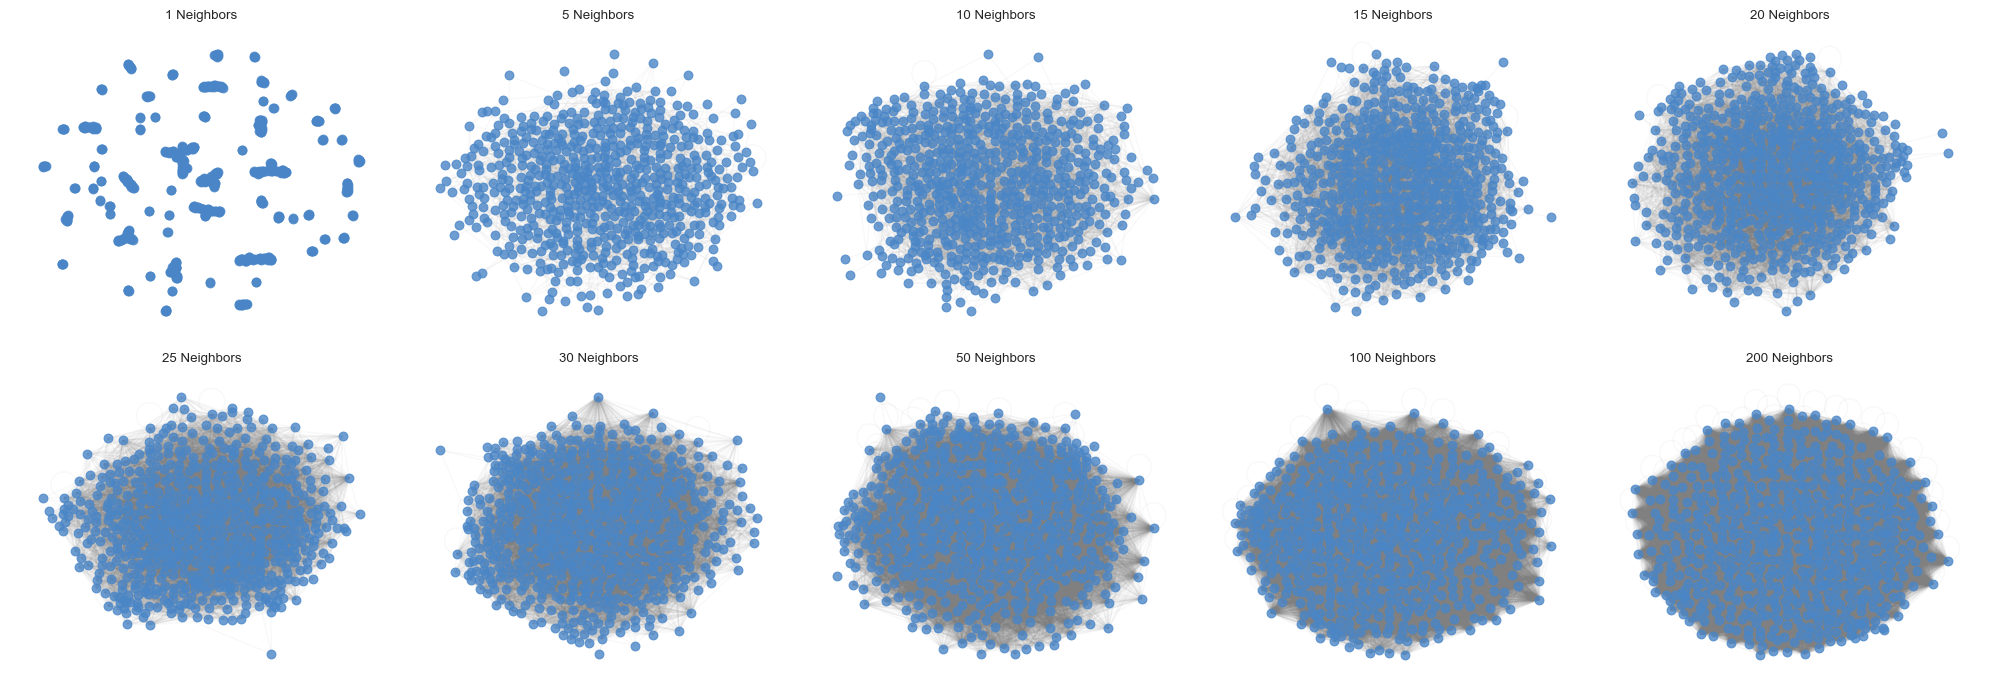

In [21]:
from fa2_modified import ForceAtlas2
import matplotlib.pyplot as plt
import networkx as nx

fig, axs = plt.subplots(
    nrows=2,
    ncols=5,

)

axs = axs.flatten()

all_positions = []

for i, (n_neighbor, G) in enumerate(zip(n_neighbors, graphs)):

    forceatlas2 = ForceAtlas2(
        # Behavior alternatives
        outboundAttractionDistribution=True,  # Dissuade hubs
        linLogMode=False,  # NOT IMPLEMENTED
        adjustSizes=False,  # Prevent overlap (NOT IMPLEMENTED)
        edgeWeightInfluence=1.0,

        # Performance
        jitterTolerance=1.0,  # Tolerance
        barnesHutOptimize=True,
        barnesHutTheta=1.2,
        multiThreaded=False,  # NOT IMPLEMENTED

        # Tuning
        scalingRatio=2.0,
        strongGravityMode=False,
        gravity=1.0,

        # Log
        verbose=True)

    positions = forceatlas2.forceatlas2_networkx_layout(G, pos=None, iterations=1000)

    all_positions.append(positions)

    testing_data[f"{n_neighbors} Positions"] = positions

    nx.draw_networkx_nodes(G, positions, node_size=40, node_color="#4a86c7", alpha=0.8, ax=axs[i])
    nx.draw_networkx_edges(G, positions, edge_color="gray", alpha=0.05, ax=axs[i])

    axs[i].axis('off')
    axs[i].set_title(f"{n_neighbor} Neighbors")

fig.set_size_inches((20, 7))
plt.tight_layout()

In [22]:
fig.savefig(
    "digital_family_models_n_neighbors.pdf", dpi=300, bbox_inches="tight"
)

In [23]:
from joblib import dump

with open("all_positions.pkl", "wb") as f:
    dump(all_positions, f)

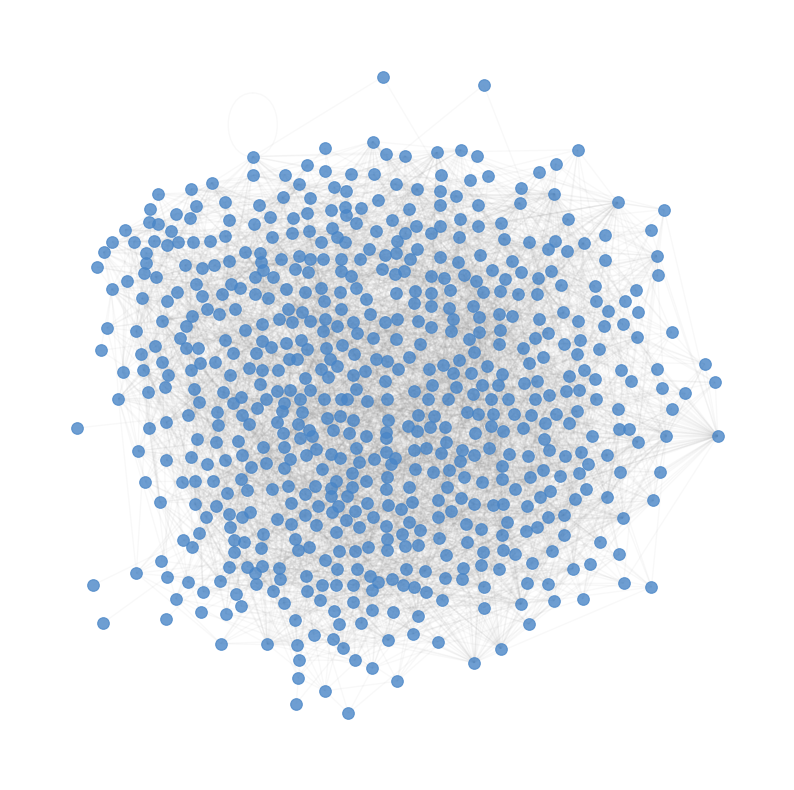

In [24]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots()

nx.draw_networkx_nodes(graphs[2], all_positions[2], node_size=70, node_color="#4a86c7", alpha=0.8, ax=ax)
nx.draw_networkx_edges(graphs[2], all_positions[2], edge_color="gray", alpha=0.05, ax=ax)

fig.set_size_inches((10, 10))
ax.axis('off')
plt.show()

In [25]:
fig.savefig("graph.pdf", dpi=300, bbox_inches="tight")